### Plotting the Normalised Frequency for each length in query.bed

Calculating the fragment length and normalising them.

In [2]:
import matplotlib.pyplot as plt
from collections import defaultdict

length_distribution = defaultdict(int)
total_fragment_count = 0

with open("query.bed", "r") as fragment_file:
    for line in fragment_file:
        fields = line.strip().split()
        start_position = int(fields[1])
        end_position = int(fields[2])
        fragment_length = end_position - start_position
        if fragment_length > 0:
            length_distribution[fragment_length] += 1
            total_fragment_count += 1

fragment_lengths = sorted(length_distribution)
normalized_frequencies = [length_distribution[length] / total_fragment_count for length in fragment_lengths]

Plotting the Fragment Length vs. Normalised Frequency.

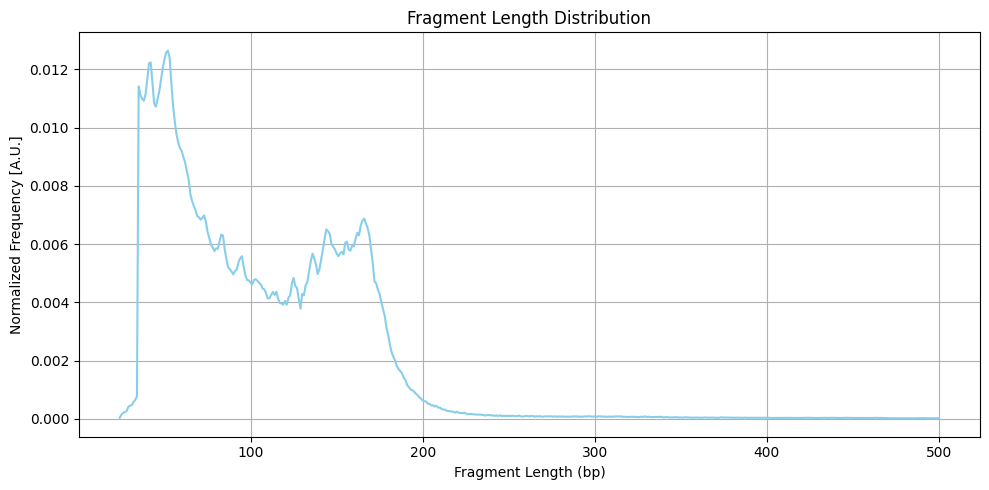

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(fragment_lengths, normalized_frequencies, color='skyblue')
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

### Rescaling of query along the reference.

Loading query.bed and compute raw length distribution.

In [4]:
query_length_distribution = defaultdict(int)
query_fragment_count = 0

with open("query.bed", "r") as query_file:
    for line in query_file:
        fields = line.strip().split()
        if len(fields) < 3:
            continue
        try:
            start_position = int(fields[1])
            end_position = int(fields[2])
            fragment_length = end_position - start_position
            if fragment_length > 0:
                query_length_distribution[fragment_length] += 1
                query_fragment_count += 1
        except ValueError:
            continue

Normalising the raw queries.

In [5]:
query_lengths = sorted(query_length_distribution)
query_normalized_frequencies = [query_length_distribution[length] / query_fragment_count for length in query_lengths]

Loading the reference data.

In [6]:
reference_length_distribution = {}
with open("reference.hist") as reference_file:
    for line in reference_file:
        parts = line.strip().split()
        if len(parts) >= 2:
            fragment_length = int(parts[0])
            frequency = float(parts[1])
            reference_length_distribution[fragment_length] = frequency

total_reference_frequency = sum(reference_length_distribution.values())
normalized_reference_distribution = {length: freq / total_reference_frequency 
                                    for length, freq in reference_length_distribution.items()}

Plotting the original query vs. reference.

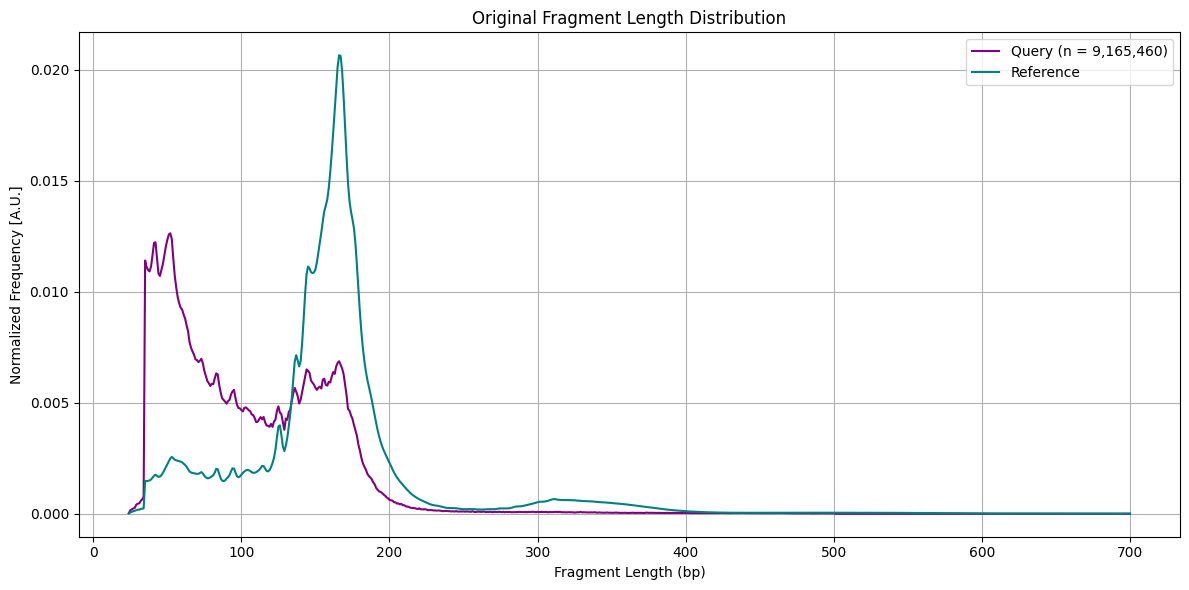

In [7]:
all_fragment_lengths = sorted(set(query_lengths) | set(normalized_reference_distribution.keys()))

plt.figure(figsize=(12, 6))

# Raw query (like expected plot)
plt.plot(all_fragment_lengths, [query_length_distribution.get(length, 0) / query_fragment_count for length in all_fragment_lengths],
         color='purple', label=f"Query (n = {query_fragment_count:,})")

# Reference
plt.plot(all_fragment_lengths, [normalized_reference_distribution.get(length, 0) for length in all_fragment_lengths],
         color='teal', label="Reference")

plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Original Fragment Length Distribution")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()